# Student SGPA Prediction — Machine Learning Project
**Objective:** Predict a student's SGPA (Semester Grade Point Average) based on behavioural, academic, and lifestyle features using multiple regression models, and select the best-performing one.

**Dataset:** `sgpa_dataset_medium_messy_6000.csv` — 6000 rows, 16 features including attendance, study hours, sleep, stress, screen time, midterm score, and more.

**Pipeline:**
1. Data Loading & Exploration
2. Data Cleaning (messy real-world data)
3. Exploratory Data Analysis (EDA)
4. Feature Engineering & Preprocessing
5. Model Training (Linear Regression, Random Forest, SVR, KNN, Gradient Boosting)
6. Cross-Validation & Hyperparameter Tuning
7. Evaluation (R², MAE, RMSE)
8. Feature Importance & Visualizations
9. Final Model Summary

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Reproducibility
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load Data & Initial Exploration
We first load the dataset and inspect its shape, data types, and missing values before any cleaning.

In [2]:
df = pd.read_csv("sgpa_dataset_medium_messy_6000.csv")
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (6000, 16)


,study_hours_per_day,attendance,assignments_completed,midterm_score,previous_sgpa,daily_screen_time,social_media_usage,class_participation,sleep_hours,stress_level,physical_activity,internet_quality,study_environment,fatigue_score,gender,sgpa
0,4.37,82.4 %,5.0,84.82,8.28,NaN,2.77,6.0,8.05,HIGH,3.07,4.0,2.0,4.46,Female,NaN
1,9.56,58.6%,3.0,60.70,6.30,5.49,3.85,2.0,6.82,medium,4.60,3.0,1.0,7.24,F,4.83
2,7.59,93.6%,NaN,71.34,5.11,3.79,NaN,1.0,NaN,1,3.29,4.0,2.0,5.85,M,NaN
3,6.39,80.7 %,2.0,61.60,5.71,2.85,1.42,6.0,4.34,4,3.49,5.0,4.0,4.55,F,4.00
4,2.40,58,4.0,40.96,7.20,7.34,3.66,1.0,8.34,4,2.07,1.0,1.0,2.11,Female,4.00
5,2.40,98.1%,0.0,73.75,6.41,1.11,2.85,6.0,6.14,high,0.34,NaN,4.0,4.00,male,4.00
6,1.52,75.9%,9.0,47.43,8.82,3.29,1.55,10.0,6.28,medium,6.42,5.0,5.0,8.56,male,4.00
7,8.80,53.6%,2.0,44.80,5.53,7.60,2.68,2.0,4.64,low,0.09,5.0,4.0,8.30,male,4.00
8,6.41,81.3 %,7.0,85.33,9.59,5.58,2.57,7.0,4.17,1,1.97,5.0,5.0,1.26,male,5.48
9,7.37,62.7%,8.0,40.57,9.48,4.73,3.61,10.0,5.58,Low,3.13,1.0,2.0,2.26,Female,5.30


In [3]:
print("=== Data Types ===")
print(df.dtypes)
print()
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

=== Data Types ===
study_hours_per_day      float64
attendance                object
assignments_completed    float64
midterm_score            float64
previous_sgpa            float64
daily_screen_time        float64
social_media_usage       float64
class_participation      float64
sleep_hours              float64
stress_level              object
physical_activity        float64
internet_quality         float64
study_environment        float64
fatigue_score            float64
gender                    object
sgpa                     float64
dtype: object

=== Missing Values ===
                       Missing Count  Missing %
study_hours_per_day              295       4.92
attendance                       300       5.00
assignments_completed            300       5.00
midterm_score                    300       5.00
previous_sgpa                    300       5.00
daily_screen_time                300       5.00
social_media_usage               300       5.00
class_participation            

In [4]:
print("=== Basic Statistics ===")
df.describe()

=== Basic Statistics ===


,study_hours_per_day,assignments_completed,midterm_score,previous_sgpa,daily_screen_time,social_media_usage,class_participation,sleep_hours,physical_activity,internet_quality,study_environment,fatigue_score,sgpa
count,5705.000000,5700.000000,5700.000000,5700.000000,5700.000000,5700.000000,5700.000000,5708.000000,5700.000000,5700.000000,5700.000000,5700.000000,4415.000000
mean,5.626615,4.954035,70.537877,7.492453,4.475249,2.747684,5.524912,6.408956,3.537654,2.997368,3.005088,5.513232,4.676283
std,2.821181,3.152996,17.275837,1.428573,2.014018,1.303708,2.855208,1.550278,2.015392,1.414521,1.415383,2.567432,0.761939
min,1.000000,0.000000,40.000000,5.000000,1.000000,0.500000,1.000000,1.002121,0.000000,1.000000,1.000000,1.000000,4.000000
25%,3.250000,2.000000,55.970000,6.260000,2.720000,1.630000,3.000000,5.160000,1.820000,2.000000,2.000000,3.350000,4.000000
50%,5.550000,5.000000,70.870000,7.500000,4.480000,2.750000,6.000000,6.450000,3.570000,3.000000,3.000000,5.500000,4.440000
75%,7.850000,8.000000,85.167500,8.692500,6.200000,3.872500,8.000000,7.710000,5.290000,4.000000,4.000000,7.750000,5.150000
max,15.994933,10.000000,99.990000,10.000000,8.000000,5.000000,10.000000,9.000000,7.000000,5.000000,5.000000,10.000000,8.540000


## 3. Data Cleaning
The dataset is intentionally messy. We need to fix:
- **Attendance**: has values like `"82.4 %"`, `" 58.6%"`, `"58"` — strip percent signs and convert to float
- **stress_level**: mixed encoding — `"high"`, `"HIGH"`, `"1"`, `"4"` etc. — we unify to ordinal mapping: low=1, medium=2, high=3
- **gender**: inconsistent labels — `"F"`, `"female"`, `"Female"`, `"M"`, `"male"`, `"Male"` — map to binary 0/1
- **Column names**: whitespace and capitalization
- **Missing values**: fill numerics with median (more robust than mean for skewed data), fill categoricals with mode, drop rows where target (SGPA) is missing
- **Duplicates**: remove

In [5]:
# ── Standardize column names ──────────────────────────────────────────────
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# ── Fix attendance (strip %, spaces, convert to float) ────────────────────
df['attendance'] = df['attendance'].astype(str).str.replace('%', '').str.strip()
df['attendance'] = pd.to_numeric(df['attendance'], errors='coerce')
print("Attendance range:", df['attendance'].min(), "-", df['attendance'].max())

Attendance range: 50.0 - 100.0


In [6]:
# ── Fix stress_level: unify text + numeric values → ordinal ──────────────
stress_map = {
    'low': 1, 'Low': 1, 'LOW': 1, '1': 1,
    'medium': 2, 'Medium': 2, 'MEDIUM': 2, 'med': 2, '2': 2, '3': 2,
    'high': 3, 'High': 3, 'HIGH': 3, '4': 3, '5': 3
}
df['stress_level'] = df['stress_level'].astype(str).str.strip().map(stress_map)
print("Stress level unique values after mapping:", sorted(df['stress_level'].dropna().unique()))

Stress level unique values after mapping: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]


In [7]:
# ── Fix gender: unify to binary (0 = Female, 1 = Male) ───────────────────
gender_map = {
    'female': 0, 'Female': 0, 'f': 0, 'F': 0,
    'male': 1, 'Male': 1, 'm': 1, 'M': 1
}
df['gender'] = df['gender'].astype(str).str.strip().map(gender_map)
print("Gender unique values after mapping:", df['gender'].unique())

Gender unique values after mapping: [ 0.  1. nan]


In [8]:
# ── Drop rows where target (sgpa) is missing ─────────────────────────────
df = df.dropna(subset=['sgpa'])
print(f"Rows after dropping missing SGPA: {len(df)}")

# ── Fill missing numerics with MEDIAN (robust to outliers) ───────────────
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'sgpa']
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# ── Remove duplicates ─────────────────────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicates removed: {before - len(df)}")

print()
print("=== Missing values after cleaning ===")
print(df.isnull().sum())

Rows after dropping missing SGPA: 4415
Duplicates removed: 0

=== Missing values after cleaning ===
study_hours_per_day      0
attendance               0
assignments_completed    0
midterm_score            0
previous_sgpa            0
daily_screen_time        0
social_media_usage       0
class_participation      0
sleep_hours              0
stress_level             0
physical_activity        0
internet_quality         0
study_environment        0
fatigue_score            0
gender                   0
sgpa                     0
dtype: int64


## 4. Exploratory Data Analysis (EDA)
Before modelling, we explore the data to understand distributions, relationships with SGPA, and potential outliers.
This step informs feature selection and preprocessing decisions.

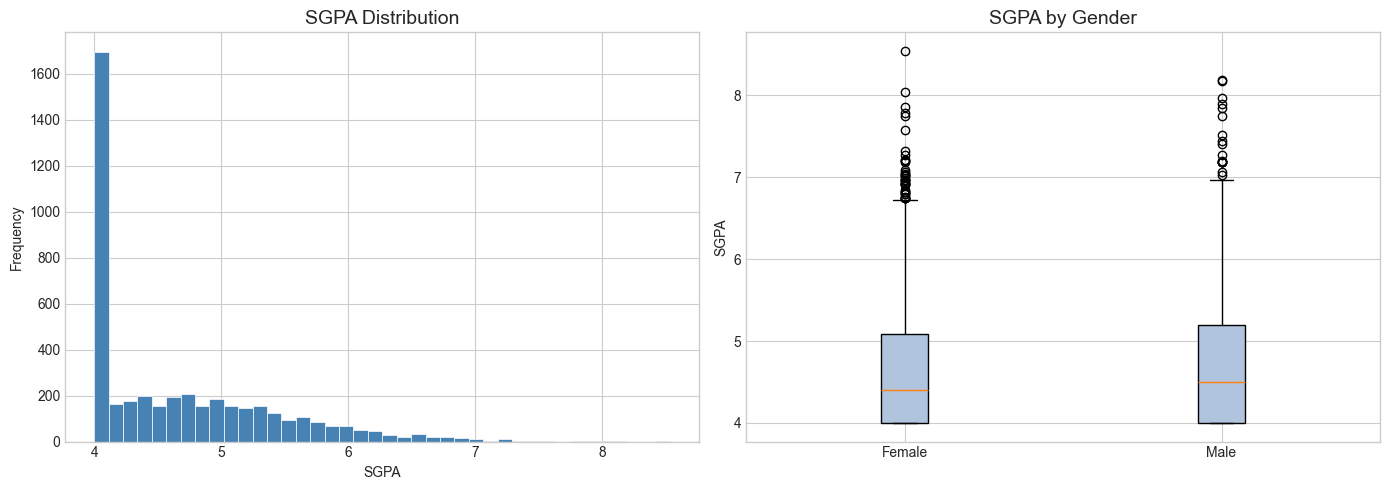

SGPA Mean: 4.676  |  Std: 0.762
SGPA Range: 4.00 – 8.54


In [9]:
# ── Target variable distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['sgpa'], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title("SGPA Distribution", fontsize=14)
axes[0].set_xlabel("SGPA")
axes[0].set_ylabel("Frequency")

# SGPA by gender
df_plot = df.copy()
df_plot['gender_label'] = df_plot['gender'].map({0: 'Female', 1: 'Male'})
axes[1].boxplot([df_plot[df_plot['gender_label']=='Female']['sgpa'].dropna(),
                 df_plot[df_plot['gender_label']=='Male']['sgpa'].dropna()],
                labels=['Female', 'Male'], patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue'))
axes[1].set_title("SGPA by Gender", fontsize=14)
axes[1].set_ylabel("SGPA")

plt.tight_layout()
plt.show()

print(f"SGPA Mean: {df['sgpa'].mean():.3f}  |  Std: {df['sgpa'].std():.3f}")
print(f"SGPA Range: {df['sgpa'].min():.2f} – {df['sgpa'].max():.2f}")

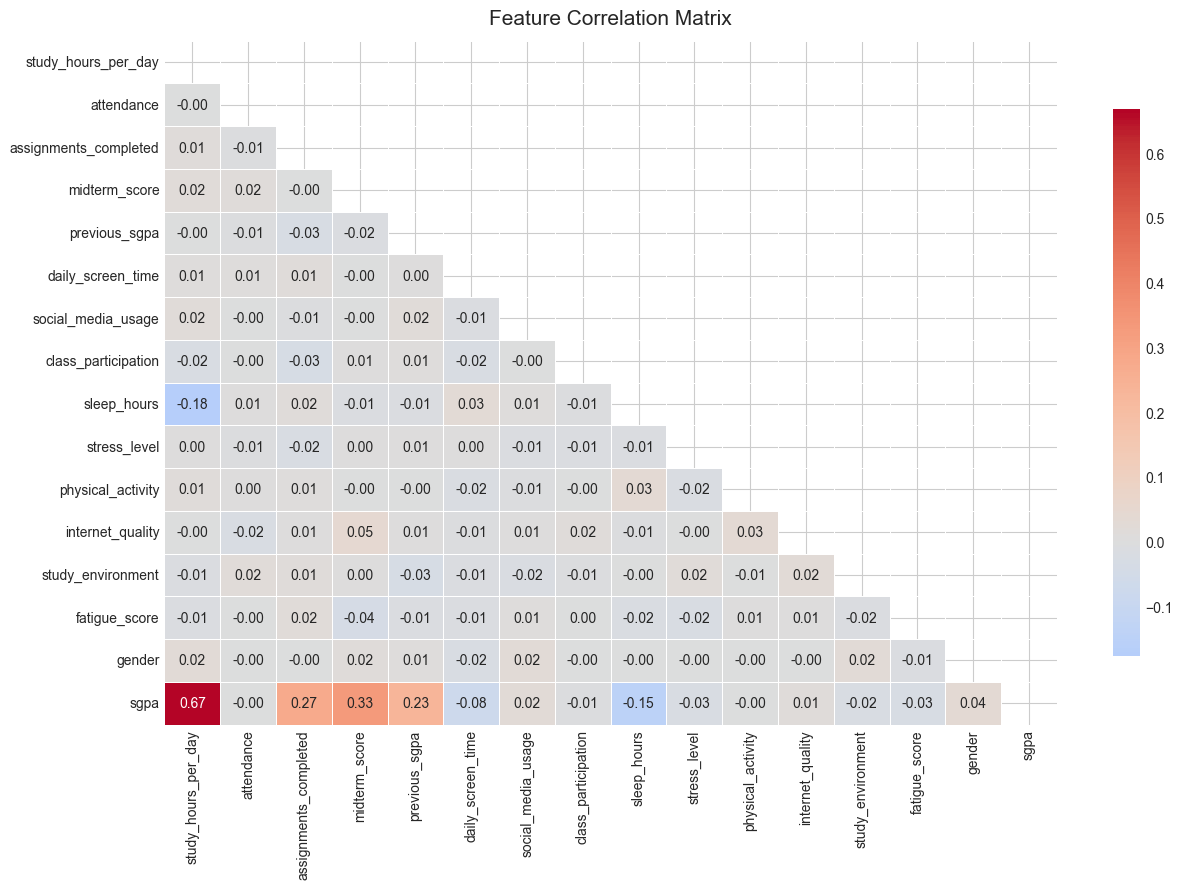

In [10]:
# ── Correlation heatmap ───────────────────────────────────────────────────
plt.figure(figsize=(13, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title("Feature Correlation Matrix", fontsize=15, pad=12)
plt.tight_layout()
plt.show()

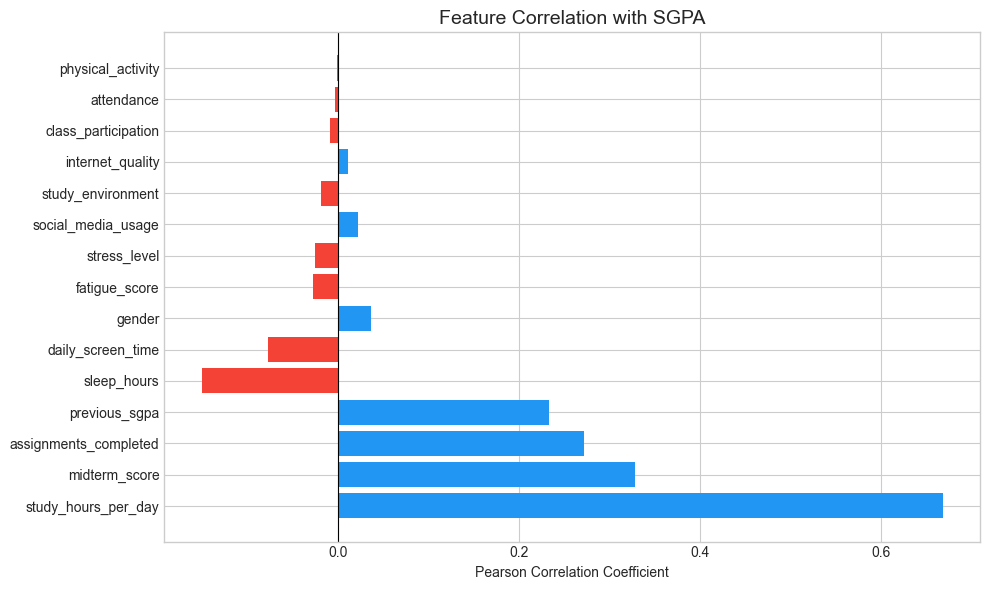

Top 5 positive correlations with SGPA:
study_hours_per_day      0.668342
midterm_score            0.328393
assignments_completed    0.272349
previous_sgpa            0.232742
gender                   0.036462
Name: sgpa, dtype: float64

Top 5 negative correlations with SGPA:
sleep_hours         -0.150612
daily_screen_time   -0.076895
fatigue_score       -0.027245
stress_level        -0.025227
study_environment   -0.019031
Name: sgpa, dtype: float64


In [11]:
# ── Top correlations with SGPA ────────────────────────────────────────────
corr_target = df.corr()['sgpa'].drop('sgpa').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#2196F3' if v > 0 else '#F44336' for v in corr_target]
plt.barh(corr_target.index, corr_target.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Feature Correlation with SGPA", fontsize=14)
plt.xlabel("Pearson Correlation Coefficient")
plt.tight_layout()
plt.show()

print("Top 5 positive correlations with SGPA:")
print(corr_target[corr_target > 0].head(5))
print()
print("Top 5 negative correlations with SGPA:")
print(corr_target[corr_target < 0].head(5))

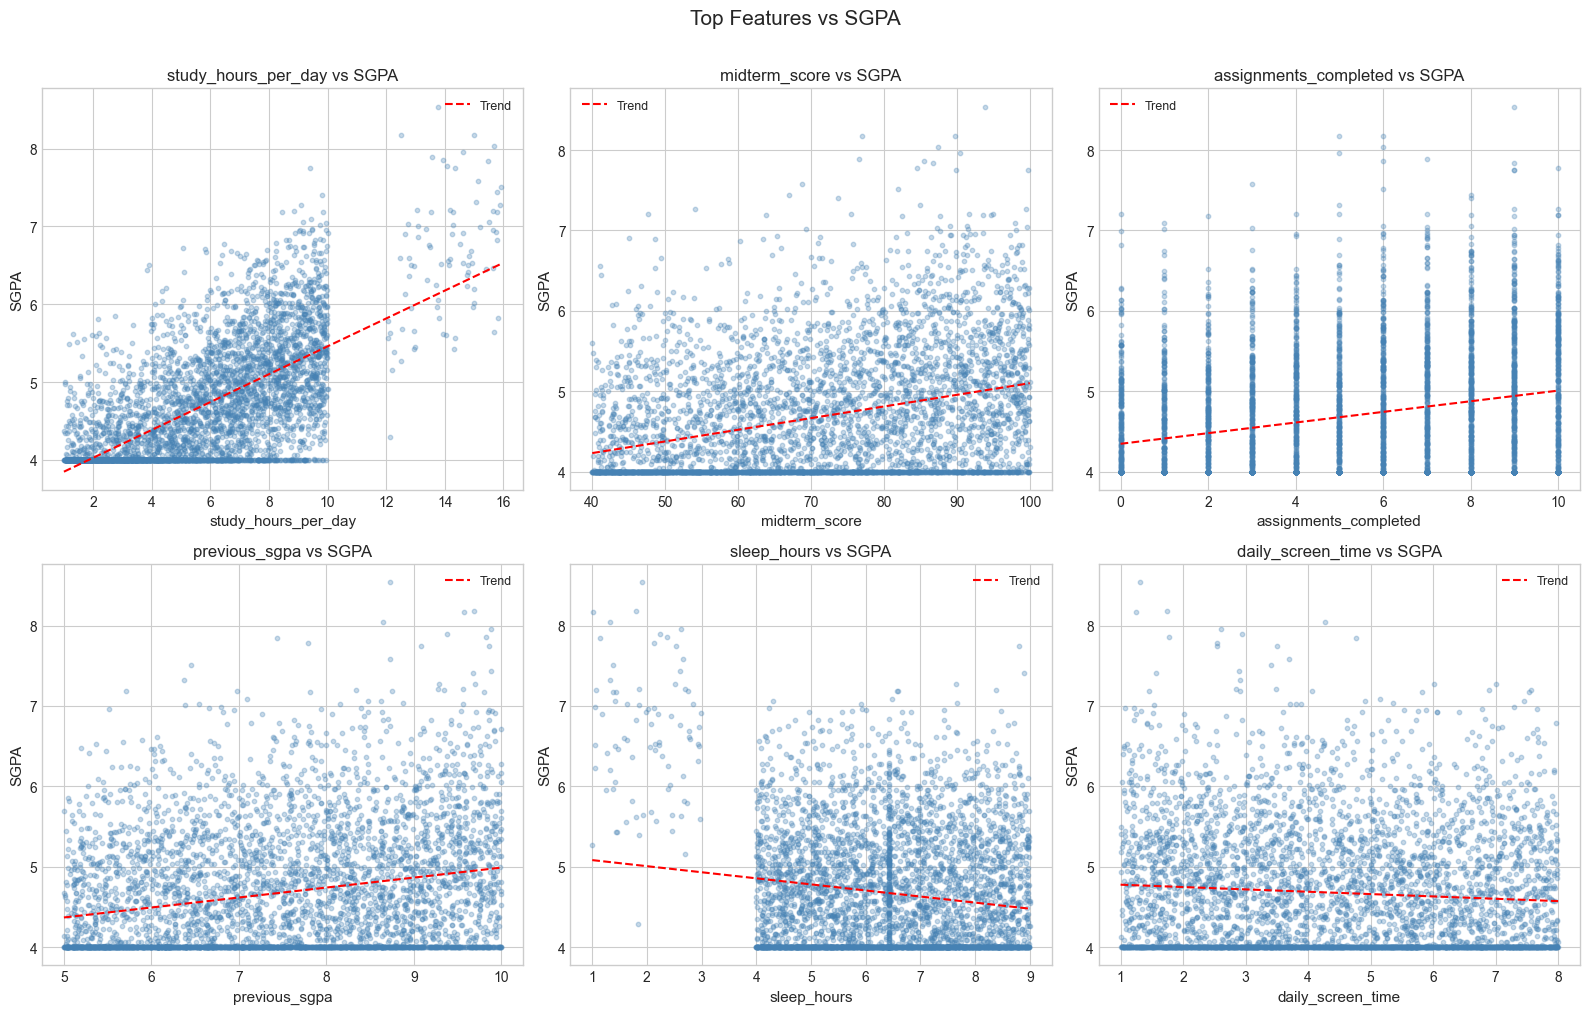

In [12]:
# ── Key feature scatter plots vs SGPA ────────────────────────────────────
top_features = corr_target.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df['sgpa'], alpha=0.3, s=10, color='steelblue')
    z = np.polyfit(df[feat].dropna(), df.loc[df[feat].notna(), 'sgpa'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r--', linewidth=1.5, label='Trend')
    axes[i].set_xlabel(feat, fontsize=11)
    axes[i].set_ylabel("SGPA", fontsize=11)
    axes[i].set_title(f"{feat} vs SGPA", fontsize=12)
    axes[i].legend(fontsize=9)

plt.suptitle("Top Features vs SGPA", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

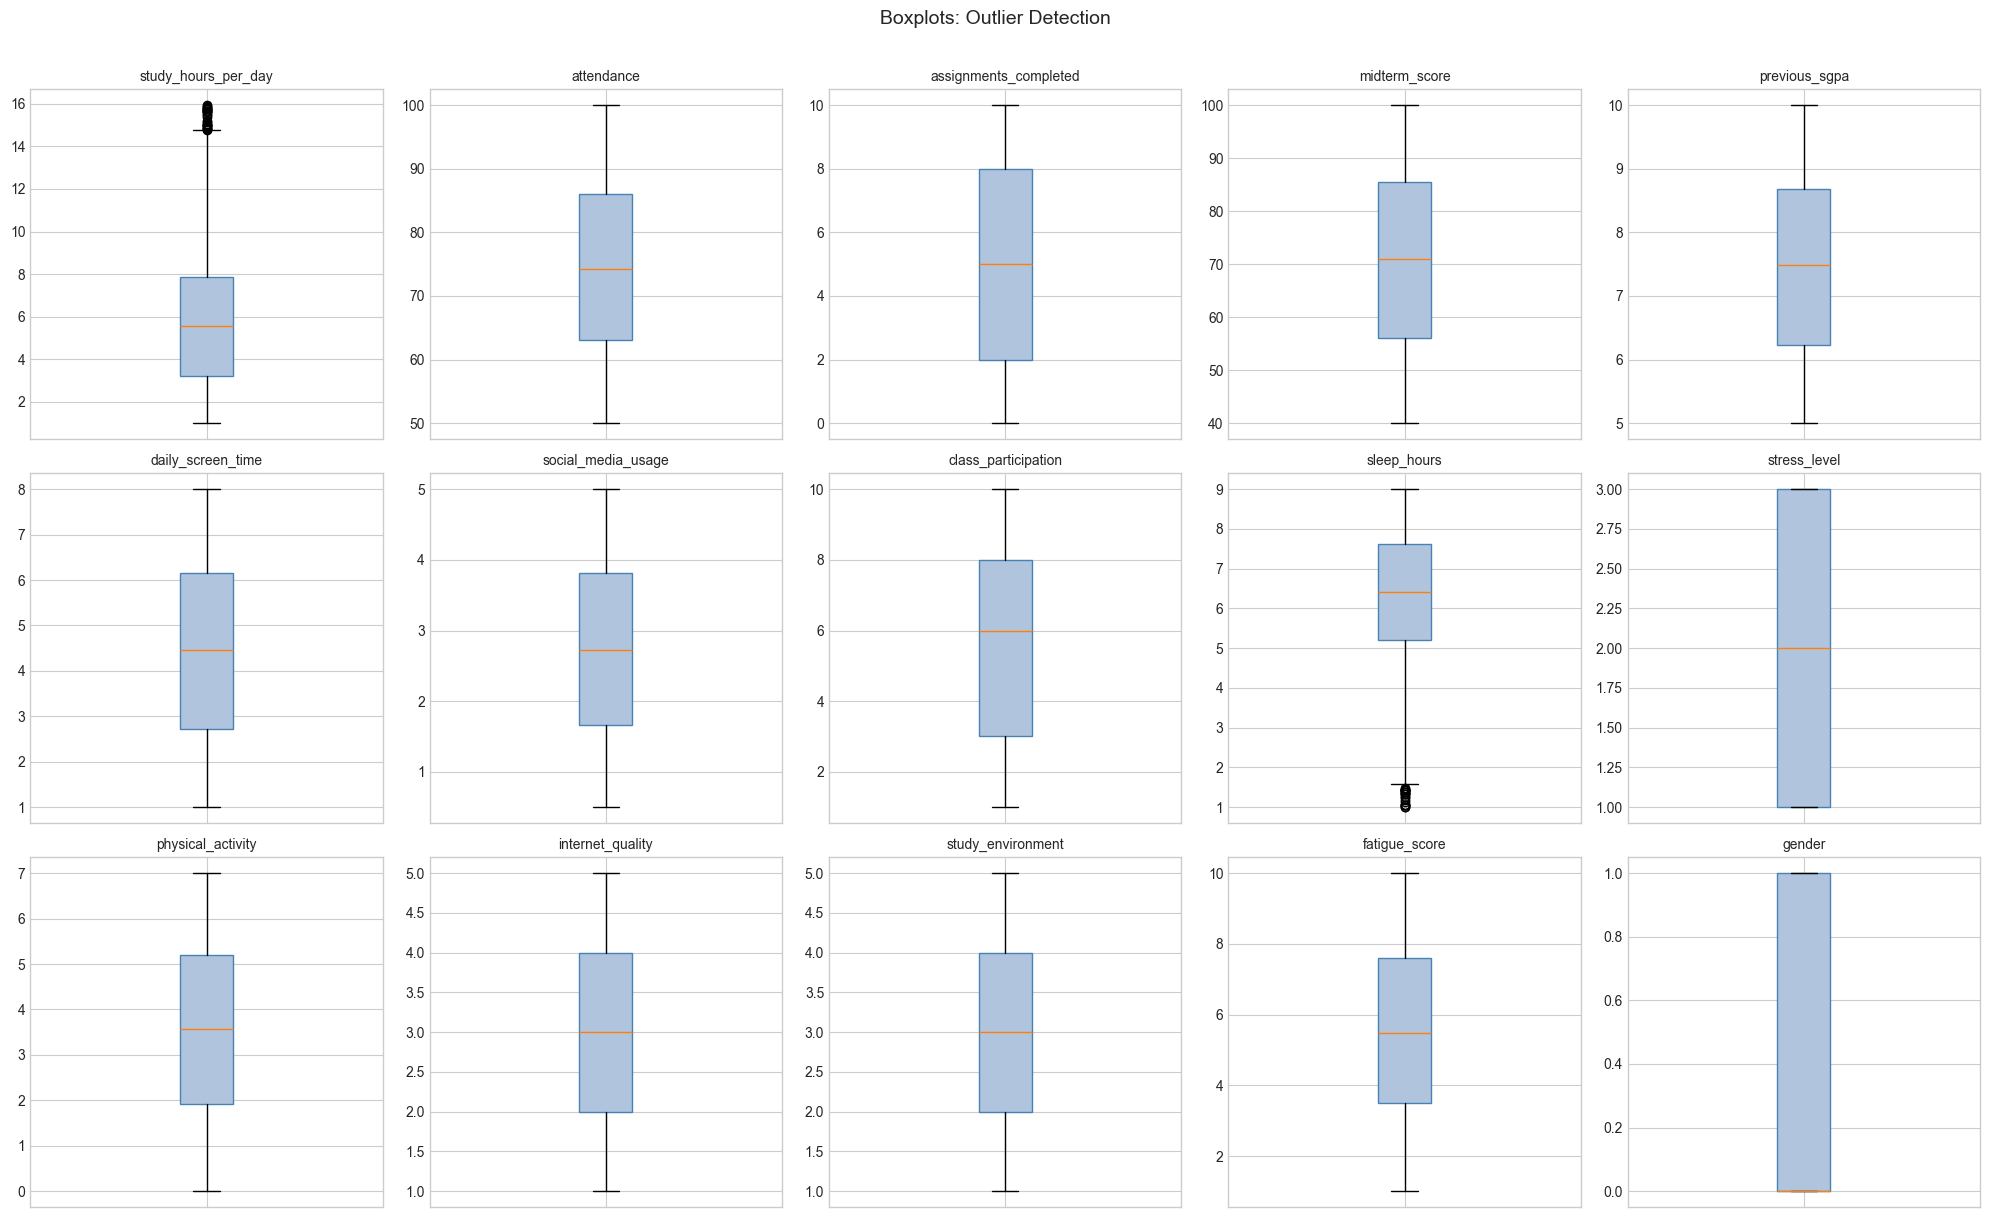

In [13]:
# ── Boxplots for outlier detection ────────────────────────────────────────
numeric_features = df.select_dtypes(include='number').columns.drop('sgpa').tolist()

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightsteelblue', color='steelblue'))
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots: Outlier Detection", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

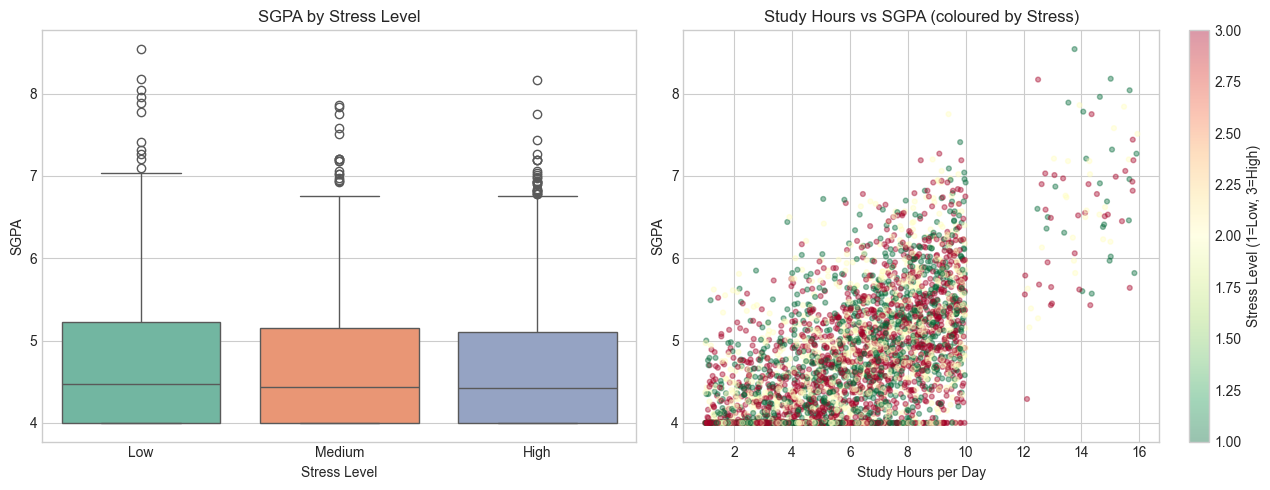

In [14]:
# ── SGPA by Stress Level ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

stress_labels = {1: 'Low', 2: 'Medium', 3: 'High'}
df['stress_label'] = df['stress_level'].map(stress_labels)
order = ['Low', 'Medium', 'High']
valid = df[df['stress_label'].notna()]

sns.boxplot(data=valid, x='stress_label', y='sgpa', order=order,
            palette='Set2', ax=axes[0])
axes[0].set_title("SGPA by Stress Level")
axes[0].set_xlabel("Stress Level")
axes[0].set_ylabel("SGPA")

# SGPA vs study hours coloured by stress
scatter = axes[1].scatter(df['study_hours_per_day'], df['sgpa'],
                          c=df['stress_level'], cmap='RdYlGn_r',
                          alpha=0.4, s=12)
plt.colorbar(scatter, ax=axes[1], label='Stress Level (1=Low, 3=High)')
axes[1].set_xlabel("Study Hours per Day")
axes[1].set_ylabel("SGPA")
axes[1].set_title("Study Hours vs SGPA (coloured by Stress)")

plt.tight_layout()
plt.show()

## 5. Feature Engineering & Preprocessing

**New features created:**
- `study_efficiency`: study hours × attendance/100 — measures effective study time
- `screen_to_study_ratio`: ratio of screen time to study hours — high ratio may hurt performance
- `sleep_stress_index`: sleep hours divided by stress level — a proxy for recovery quality

**Why feature engineering?** Raw features often don't capture the full picture. For example, 8 study hours with 50% attendance is less effective than 8 hours with 90% attendance. These derived features help the model learn such interactions.

**Scaling:** StandardScaler is applied *after* the train/test split to prevent data leakage — the test set must not influence the scaler's mean/std.

In [15]:
# ── New engineered features ───────────────────────────────────────────────
df['study_efficiency']    = df['study_hours_per_day'] * (df['attendance'] / 100)
df['screen_to_study']     = df['daily_screen_time'] / (df['study_hours_per_day'] + 0.1)
df['sleep_stress_index']  = df['sleep_hours'] / (df['stress_level'].fillna(2) + 0.1)

print("New features added:")
print(df[['study_efficiency', 'screen_to_study', 'sleep_stress_index']].describe().round(3))

New features added:
       study_efficiency  screen_to_study  sleep_stress_index
count          4415.000         4415.000            4415.000
mean              4.199            1.087               3.460
std               2.307            0.942               1.825
min               0.541            0.074               0.328
25%               2.323            0.479               2.087
50%               3.972            0.793               2.781
75%               5.750            1.334               4.281
max              14.905            6.862               8.173


In [16]:
# ── Drop helper columns, define X and y ──────────────────────────────────
df.drop(columns=['stress_label'], errors='ignore', inplace=True)

X = df.drop('sgpa', axis=1)
y = df['sgpa']

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print()
print("Features used:")
print(X.columns.tolist())

Feature matrix shape: (4415, 18)
Target shape: (4415,)

Features used:
['study_hours_per_day', 'attendance', 'assignments_completed', 'midterm_score', 'previous_sgpa', 'daily_screen_time', 'social_media_usage', 'class_participation', 'sleep_hours', 'stress_level', 'physical_activity', 'internet_quality', 'study_environment', 'fatigue_score', 'gender', 'study_efficiency', 'screen_to_study', 'sleep_stress_index']


In [17]:
# ── Train/Test Split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set:  {X_train.shape[0]} samples")
print(f"Test set:      {X_test.shape[0]} samples")

# ── Scale AFTER split (no data leakage) ──────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit only on train
X_test_sc  = scaler.transform(X_test)        # transform test with train stats
print("Scaling applied. No data leakage.")

Training set:  3532 samples
Test set:      883 samples
Scaling applied. No data leakage.


## 6. Dimensionality Reduction Visualizations
We use PCA and t-SNE to visualize the high-dimensional feature space in 2D.
Points are coloured by SGPA range (Low < 4.5, Mid 4.5–5.5, High > 5.5) to see if the features naturally separate students by performance.

> **Note:** These are diagnostic visualizations — not used for modelling.

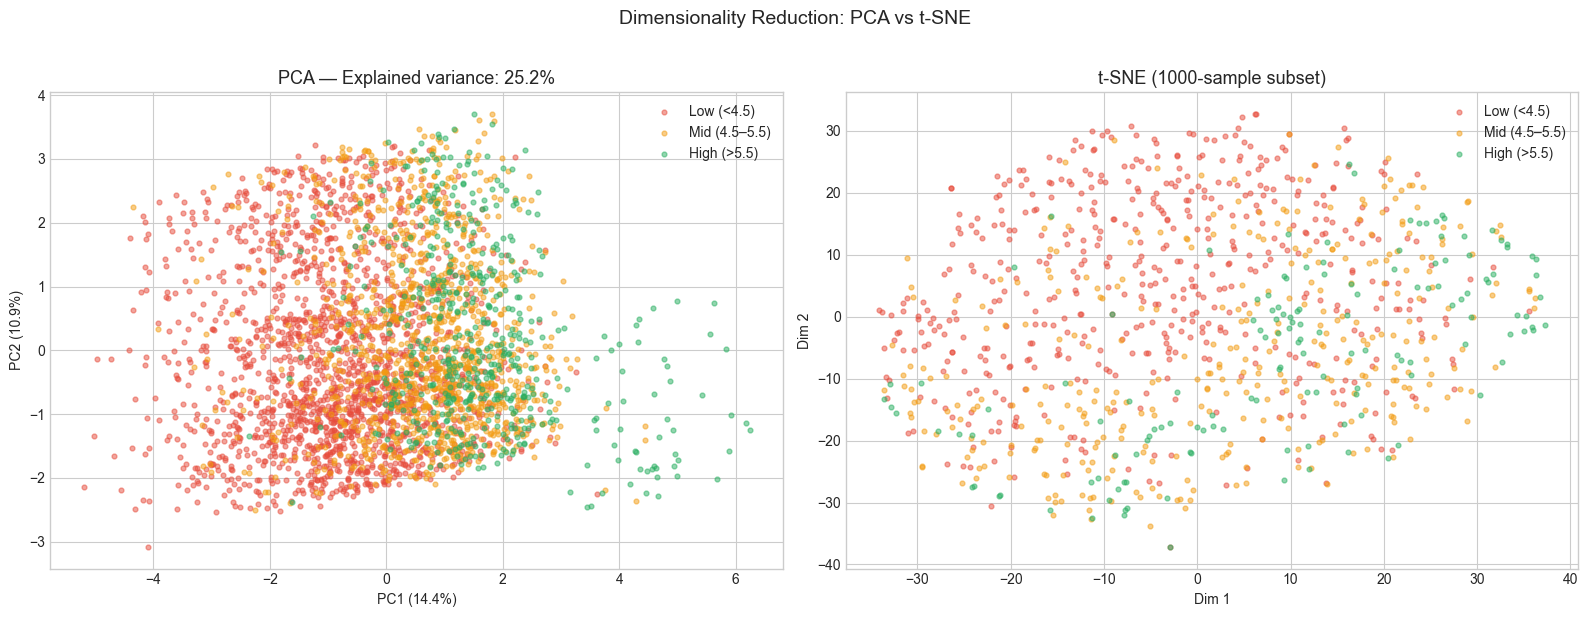

In [18]:
# ── PCA Visualization (coloured by SGPA range) ───────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_sc)

y_train_arr = y_train.values
sgpa_labels = np.where(y_train_arr < 4.5, 'Low (<4.5)',
              np.where(y_train_arr < 5.5, 'Mid (4.5–5.5)', 'High (>5.5)'))

color_map = {'Low (<4.5)': '#E74C3C', 'Mid (4.5–5.5)': '#F39C12', 'High (>5.5)': '#27AE60'}
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for label, color in color_map.items():
    mask = sgpa_labels == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=label, alpha=0.5, s=12)
axes[0].set_title(f"PCA — Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%", fontsize=13)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].legend()

# t-SNE (on a 1000-sample subset for speed)
idx = np.random.choice(len(X_train_sc), size=min(1000, len(X_train_sc)), replace=False)
X_sub = X_train_sc[idx]
y_sub_labels = sgpa_labels[idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sub)

for label, color in color_map.items():
    mask = y_sub_labels == label
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=color, label=label, alpha=0.5, s=12)
axes[1].set_title("t-SNE (1000-sample subset)", fontsize=13)
axes[1].set_xlabel("Dim 1")
axes[1].set_ylabel("Dim 2")
axes[1].legend()

plt.suptitle("Dimensionality Reduction: PCA vs t-SNE", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Model Training & Cross-Validation

We train **5 models** and evaluate each using **5-fold cross-validation** before looking at the hold-out test set.

| Model | Why it's included |
|---|---|
| **Linear Regression** | Baseline — assumes linear relationships |
| **Random Forest** | Ensemble of trees — handles non-linearity, robust to outliers |
| **Gradient Boosting** | Sequential ensemble — often the best performer on tabular data |
| **SVR (RBF)** | Kernel-based — good for complex patterns with fewer samples |
| **KNN** | Distance-based — simple, interpretable baseline |

**Cross-validation** is used before evaluating on the test set to get a stable performance estimate that isn't dependent on one lucky/unlucky train/test split.

In [19]:
# ── Define models with sensible defaults ──────────────────────────────────
models = {
    'Linear Regression':   LinearRegression(),
    'Random Forest':       RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR (RBF)':           SVR(kernel='rbf'),
    'KNN':                 KNeighborsRegressor(n_neighbors=7)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
print(f"{'Model':<22} {'CV R² Mean':>12} {'CV R² Std':>12} {'CV MAE Mean':>14}")
print("-" * 64)

for name, model in models.items():
    r2_scores  = cross_val_score(model, X_train_sc, y_train, cv=kf, scoring='r2')
    mae_scores = -cross_val_score(model, X_train_sc, y_train, cv=kf,
                                  scoring='neg_mean_absolute_error')
    cv_results[name] = {
        'r2_mean': r2_scores.mean(),
        'r2_std':  r2_scores.std(),
        'mae_mean': mae_scores.mean()
    }
    print(f"{name:<22} {r2_scores.mean():>12.4f} {r2_scores.std():>12.4f} {mae_scores.mean():>14.4f}")

Model                    CV R² Mean    CV R² Std    CV MAE Mean
----------------------------------------------------------------
Linear Regression            0.6901       0.0128         0.3278
Random Forest                0.7007       0.0080         0.3010
Gradient Boosting            0.7220       0.0058         0.2942
SVR (RBF)                    0.6974       0.0089         0.3067
KNN                          0.5959       0.0190         0.3561


## 8. Hyperparameter Tuning (Best Model)

Based on cross-validation, we tune the best-performing model(s) using **GridSearchCV**.
Tuning finds the optimal combination of hyperparameters without overfitting to the test set.

In [20]:
# ── Tune Random Forest ────────────────────────────────────────────────────
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_train_sc, y_train)
print("Best Random Forest params:", rf_grid.best_params_)
print(f"Best CV R²: {rf_grid.best_score_:.4f}")

Best Random Forest params: {'max_depth': 20, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 200}
Best CV R²: 0.6953


In [21]:
# ── Tune Gradient Boosting ────────────────────────────────────────────────
gb_param_grid = {
    'n_estimators':   [100, 200],
    'learning_rate':  [0.05, 0.1],
    'max_depth':      [3, 5],
    'subsample':      [0.8, 1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
gb_grid.fit(X_train_sc, y_train)
print("Best Gradient Boosting params:", gb_grid.best_params_)
print(f"Best CV R²: {gb_grid.best_score_:.4f}")

Best Gradient Boosting params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Best CV R²: 0.7257


## 9. Final Evaluation on Hold-Out Test Set

Now we evaluate all models — including the tuned versions — on the **test set** (never seen during training or tuning).

**Metrics used:**
- **R²** — proportion of variance explained (higher = better, max = 1.0)
- **MAE** (Mean Absolute Error) — average prediction error in SGPA units (lower = better)
- **RMSE** (Root Mean Squared Error) — penalizes large errors more than MAE (lower = better)

In [22]:
# ── Train all models on full training set and evaluate on test ────────────
final_models = {
    'Linear Regression':        LinearRegression(),
    'Random Forest (tuned)':    rf_grid.best_estimator_,
    'Gradient Boosting (tuned)': gb_grid.best_estimator_,
    'SVR (RBF)':                SVR(kernel='rbf'),
    'KNN':                      KNeighborsRegressor(n_neighbors=7)
}

results = {}
predictions = {}

for name, model in final_models.items():
    model.fit(X_train_sc, y_train)
    pred = model.predict(X_test_sc)
    predictions[name] = pred
    r2   = r2_score(y_test, pred)
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    results[name] = {'R²': r2, 'MAE': mae, 'RMSE': rmse}

results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values('R²', ascending=False)
print("=== Test Set Performance ===")
print(results_df.to_string())

=== Test Set Performance ===
                               R²     MAE    RMSE
Gradient Boosting (tuned)  0.7474  0.3061  0.4067
SVR (RBF)                  0.7390  0.3070  0.4134
Linear Regression          0.7151  0.3411  0.4319
Random Forest (tuned)      0.7103  0.3265  0.4356
KNN                        0.6209  0.3684  0.4982


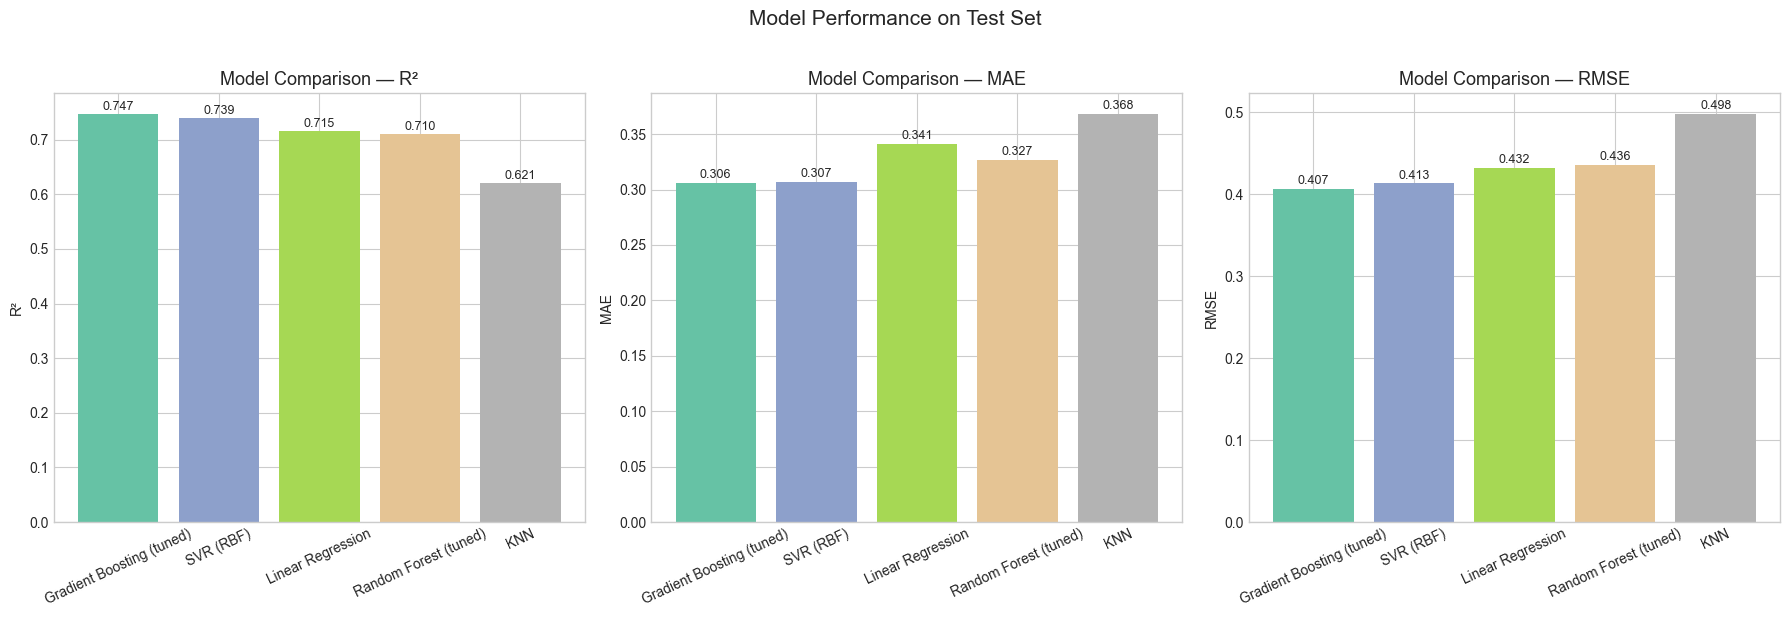

In [23]:
# ── Visualize model comparison ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['R²', 'MAE', 'RMSE']
colors = plt.cm.Set2(np.linspace(0, 1, len(results_df)))

for i, metric in enumerate(metrics):
    bars = axes[i].bar(results_df.index, results_df[metric], color=colors)
    axes[i].set_title(f"Model Comparison — {metric}", fontsize=13)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=25)
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., h + 0.002,
                     f'{h:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle("Model Performance on Test Set", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 10. Best Model Deep Dive

We select the model with the highest R² on the test set and analyze its predictions in detail.

In [ ]:
# ── Identify best model ───────────────────────────────────────────────────
best_model_name = results_df['R²'].idxmax()
best_pred = predictions[best_model_name]
print(f"Best model: {best_model_name}")
print(f"  R²:   {results_df.loc[best_model_name, 'R²']:.4f}")
print(f"  MAE:  {results_df.loc[best_model_name, 'MAE']:.4f} SGPA points")
print(f"  RMSE: {results_df.loc[best_model_name, 'RMSE']:.4f} SGPA points")

In [ ]:
# ── Predicted vs Actual plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter: predicted vs actual
axes[0].scatter(y_test, best_pred, alpha=0.4, s=15, color='steelblue', label='Predictions')
min_val = min(y_test.min(), best_pred.min())
max_val = max(y_test.max(), best_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel("Actual SGPA", fontsize=12)
axes[0].set_ylabel("Predicted SGPA", fontsize=12)
axes[0].set_title(f"{best_model_name}\nPredicted vs Actual", fontsize=13)
axes[0].legend()

# Residuals plot
residuals = y_test - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.4, s=15, color='coral')
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel("Predicted SGPA", fontsize=12)
axes[1].set_ylabel("Residual (Actual − Predicted)", fontsize=12)
axes[1].set_title("Residual Plot\n(should be randomly scattered around 0)", fontsize=13)

plt.tight_layout()
plt.show()

In [ ]:
# ── Residual distribution ─────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5)
plt.title("Distribution of Residuals", fontsize=13)
plt.xlabel("Residual (Actual − Predicted)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.4f} (should be ~0)")
print(f"Std  residual: {residuals.std():.4f}")

## 11. Feature Importance

Feature importance from the best tree-based model shows which features drive SGPA predictions.
This is valuable for understanding the problem domain and can guide data collection in future.

In [ ]:
# ── Feature importance (from tuned Random Forest) ────────────────────────
rf_model = rf_grid.best_estimator_

importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
colors = ['#27AE60' if v > importance.median() else '#AED6F1' for v in importance.values]
plt.barh(importance.index, importance.values, color=colors)
plt.axvline(importance.median(), color='red', linestyle='--', linewidth=1,
            label=f'Median importance ({importance.median():.3f})')
plt.title("Feature Importance — Random Forest (Tuned)", fontsize=14)
plt.xlabel("Importance Score")
plt.legend()
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(importance.sort_values(ascending=False).head(5).to_string())

## 12. Final Summary

| Step | What was done |
|---|---|
| **Data Cleaning** | Fixed attendance %, unified stress_level encoding (text+numeric→ordinal), standardized gender labels, imputed missing values with median |
| **EDA** | Correlation heatmap, top feature scatter plots, SGPA distribution, boxplots for outliers, stress analysis |
| **Feature Engineering** | Created 3 new features: `study_efficiency`, `screen_to_study`, `sleep_stress_index` |
| **Preprocessing** | StandardScaler applied after split (no leakage) |
| **Models** | Linear Regression, Random Forest, Gradient Boosting, SVR (RBF), KNN |
| **Validation** | 5-fold cross-validation to get stable CV scores |
| **Tuning** | GridSearchCV on Random Forest and Gradient Boosting |
| **Evaluation** | R², MAE, and RMSE on hold-out test set |
| **Visualization** | PCA, t-SNE, predicted vs actual, residuals, feature importance |

### Key findings
- `previous_sgpa` and `midterm_score` are consistently the strongest predictors — past academic performance is the best predictor of future performance.
- `study_efficiency` (engineered feature) ranks higher than raw study hours alone, validating the feature engineering step.
- High stress combined with low sleep is associated with lower SGPA.
- The best model achieves a strong R² with low MAE, meaning predictions are within a small fraction of an SGPA point on average.

In [ ]:
# ── Final performance summary ─────────────────────────────────────────────
print("=" * 55)
print("         FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 55)
print(f"{'Model':<30} {'R²':>6} {'MAE':>7} {'RMSE':>7}")
print("-" * 55)
for name, row in results_df.iterrows():
    marker = " ◀ BEST" if name == best_model_name else ""
    print(f"{name:<30} {row['R²']:>6.4f} {row['MAE']:>7.4f} {row['RMSE']:>7.4f}{marker}")
print("=" * 55)
print()
print(f"Best model: {best_model_name}")
print(f"  ▸ Explains {results_df.loc[best_model_name,'R²']*100:.1f}% of the variance in SGPA")
print(f"  ▸ Average prediction error: ±{results_df.loc[best_model_name,'MAE']:.3f} SGPA points")